In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import seaborn as sns

In [2]:
net_names = ["network3", "CNN_with_BN", "dropout_simple_CNN", "dropout_lenet5", "lenet5", "lenet4", "simplified_lenet5", "dilated_lenet5", "lenet1", "400-300-10", "400-10", "128-10"]

In [17]:
means = pd.read_json("created_files/times.json")

In [18]:
means.index = ["test_data_time", "test_time", "load_time", "forward_time"]

In [19]:
accuracy = {}
for net_name in net_names:
    df = pd.read_json("created_files/"+net_name+".json")
    accuracy[net_name] = df.at[0, "accuracy"]

means.loc["accuracy"] = accuracy

In [20]:
df = means.T

In [25]:
df

,test_data_time,test_time,load_time,forward_time,accuracy
network3,0.005265,1.809724,1.250870,0.558855,99.32
CNN_with_BN,0.005074,2.125833,1.286076,0.839757,99.38
dropout_simple_CNN,0.006890,1.843658,1.497327,0.346331,99.37
dropout_lenet5,0.005075,1.734823,1.458276,0.276547,99.19
lenet5,0.005067,1.708312,1.445999,0.262313,99.25
lenet4,0.005230,1.712035,1.473159,0.238876,99.09
simplified_lenet5,0.005216,1.413547,1.185361,0.228186,98.89
dilated_lenet5,0.005309,1.744310,1.473648,0.270663,98.94
lenet1,0.005232,1.857515,1.664073,0.193442,98.44
400-300-10,0.005053,1.250234,1.176618,0.073616,98.34


In [36]:
def pareto_front(df, time_feature):
    pareto = []
    for i, row in df.iterrows():
        dominated = False
        for j, other in df.iterrows():
            if (
                other['accuracy'] >= row['accuracy'] and
                other[time_feature] <= row[time_feature] and
                (other['accuracy'] > row['accuracy'] or
                 other[time_feature] < row[time_feature])
            ):
                dominated = True
                break
        if not dominated:
            pareto.append(i)
    return df.loc[pareto]

pareto_df = pareto_front(df, "forward_time")

In [ ]:
plt.scatter(df['inference_time'], df['accuracy'], label="Modèles")

# front de Pareto
pareto_df = pareto_df.sort_values('inference_time')
plt.plot(pareto_df['inference_time'], pareto_df['accuracy'], color='red', label="Front de Pareto")

plt.xlabel("Temps d'inférence")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

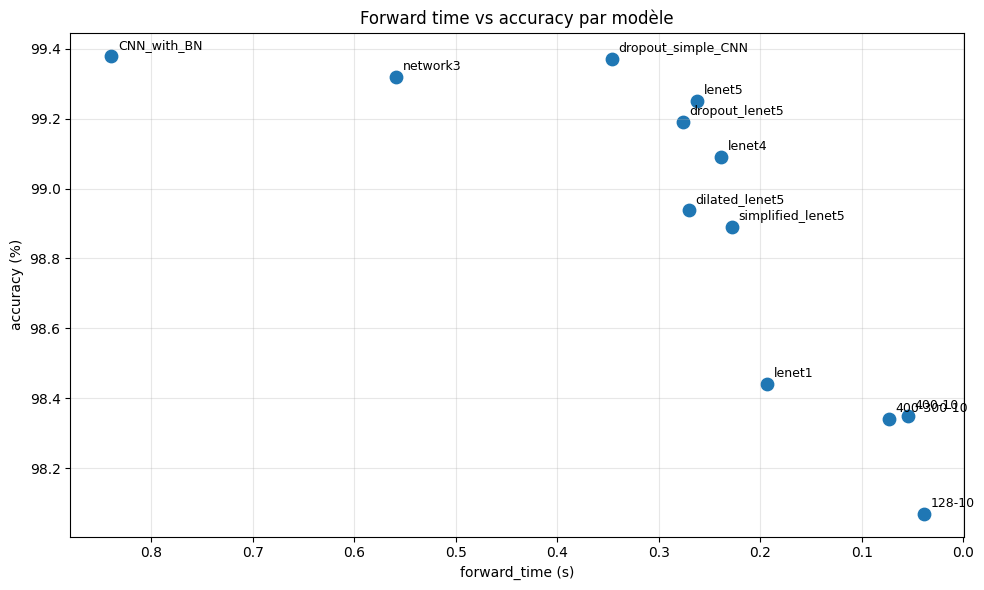

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df["forward_time"], df["accuracy"], color="tab:blue", s=80)

for net_name, row in df.iterrows():
    plt.annotate(net_name,
                 (row["forward_time"], row["accuracy"]),
                 textcoords="offset points",
                 xytext=(5, 5),
                 ha="left",
                 fontsize=9)

pareto_df = pareto_df.sort_values('inference_time')
plt.plot(pareto_df['inference_time'], pareto_df['accuracy'], color='red', label="Front de Pareto")

plt.title("Forward time vs accuracy par modèle")
plt.xlabel("forward_time (s)")
plt.ylabel("accuracy (%)")
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

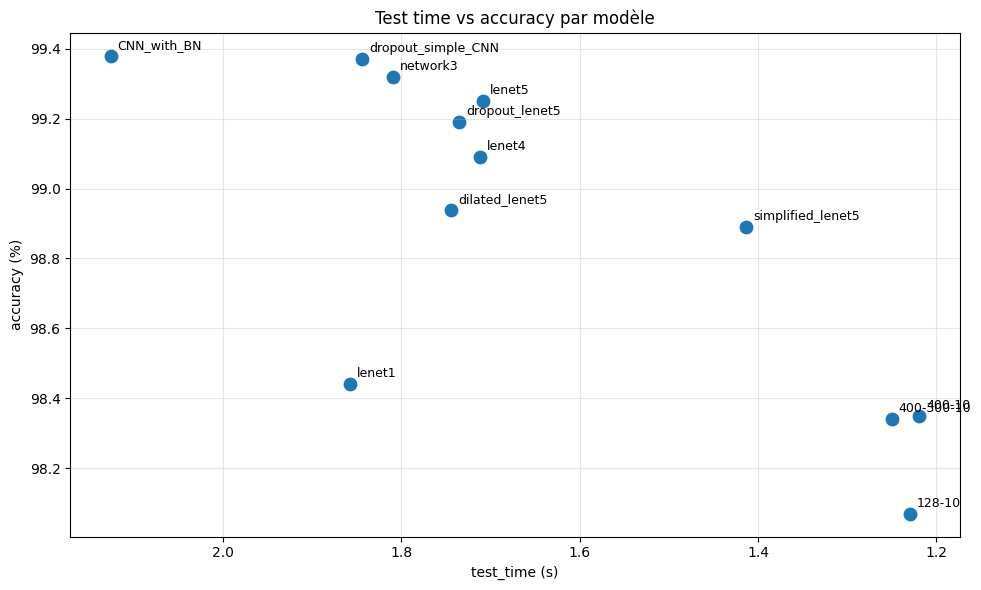

In [31]:
plt.figure(figsize=(10, 6))
plt.scatter(df["test_time"], df["accuracy"], color="tab:blue", s=80)

for net_name, row in df.iterrows():
    plt.annotate(net_name,
                 (row["test_time"], row["accuracy"]),
                 textcoords="offset points",
                 xytext=(5, 5),
                 ha="left",
                 fontsize=9)

plt.title("Test time vs accuracy par modèle")
plt.xlabel("test_time (s)")
plt.ylabel("accuracy (%)")
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

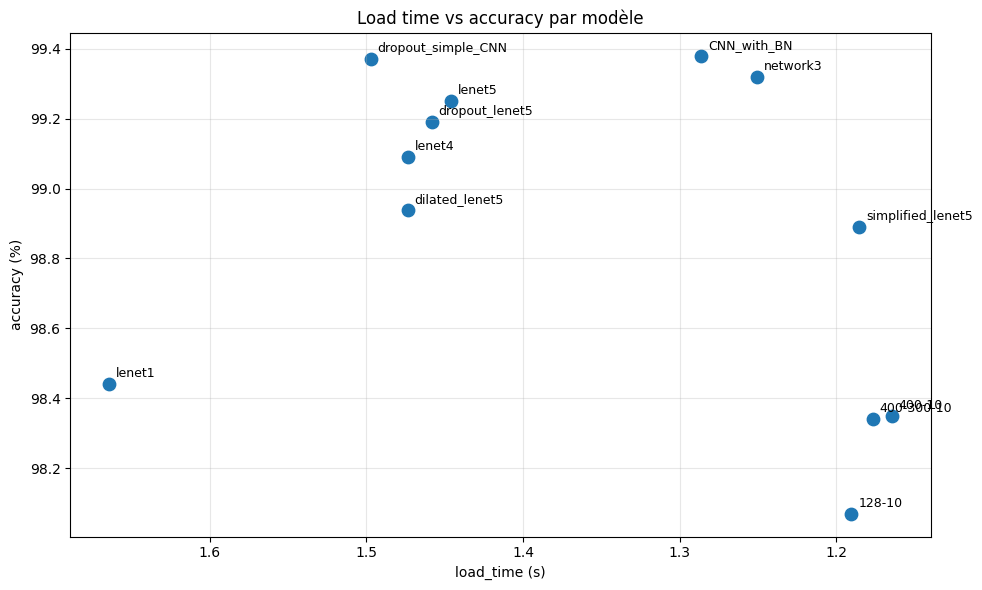

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(df["load_time"], df["accuracy"], color="tab:blue", s=80)

for net_name, row in df.iterrows():
    plt.annotate(net_name,
                 (row["load_time"], row["accuracy"]),
                 textcoords="offset points",
                 xytext=(5, 5),
                 ha="left",
                 fontsize=9)

plt.title("Load time vs accuracy par modèle")
plt.xlabel("load_time (s)")
plt.ylabel("accuracy (%)")
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

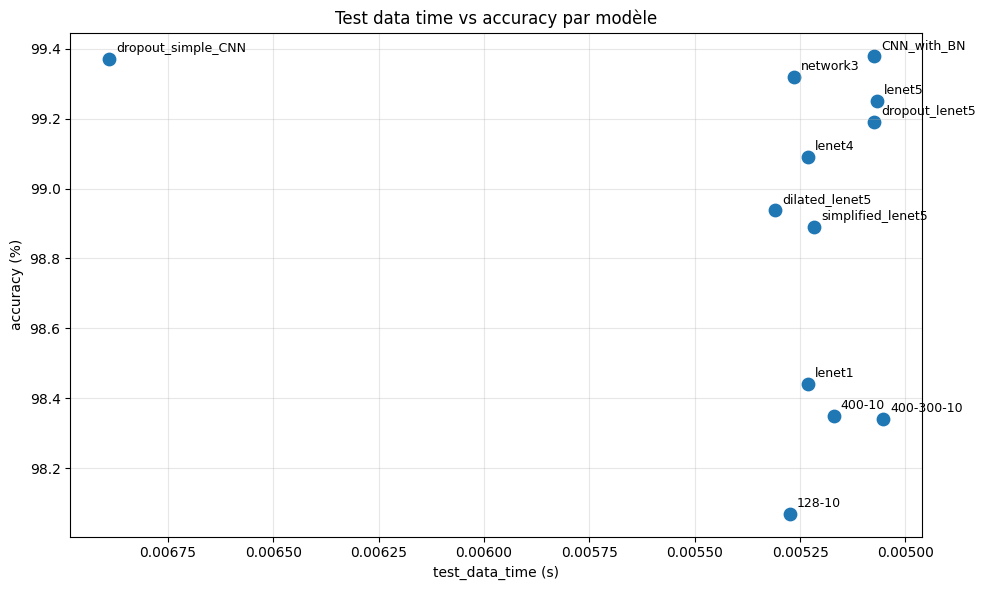

In [34]:
plt.figure(figsize=(10, 6))
plt.scatter(df["test_data_time"], df["accuracy"], color="tab:blue", s=80)

for net_name, row in df.iterrows():
    plt.annotate(net_name,
                 (row["test_data_time"], row["accuracy"]),
                 textcoords="offset points",
                 xytext=(5, 5),
                 ha="left",
                 fontsize=9)

plt.title("Test data time vs accuracy par modèle")
plt.xlabel("test_data_time (s)")
plt.ylabel("accuracy (%)")
plt.gca().invert_xaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()